# Tau Bubble Chart

Interactive notebook to inspect country-year sector bubbles using `tau`, `tau_dir`, `tau_amp`, or `tau_amp2`.
Bubble size uses sector `HFCE` as a household consumption proxy.

In [14]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz as viz
importlib.reload(viz)
prepare_country_bubble_data = viz.prepare_country_bubble_data
plot_country_bubble = viz.plot_country_bubble
import matplotlib.pyplot as plt

In [15]:
cfg = load_config('config/default.yaml')
country = 'USA'
year = 2019
metric = 'tau'  # one of: tau, tau_dir, tau_amp, tau_amp2

In [16]:
df = prepare_country_bubble_data(cfg=cfg, country=country, year=year, metric=metric)
label_top_n = len(df)
print(df[['label', 'sector_code', metric, 'hfce_proxy']].head(10).to_string(index=False))
print(f'rows={len(df)}  country={country}  year={year}  metric={metric}')

     label sector_code      tau  hfce_proxy
   USA_A01         A01 0.047964 138467.3256
   USA_A02         A02 0.025284   9027.9220
   USA_A03         A03 0.017581    665.1194
   USA_B05         B05 0.053482     12.1915
   USA_B07         B07 0.081067      1.1890
   USA_B08         B08 0.055170    382.8493
   USA_B09         B09 0.041870    378.4393
USA_C10T12      C10T12 0.027353 723393.5660
USA_C13T15      C13T15 0.028103  32831.0470
   USA_C16         C16 0.029027   6108.1489
rows=48  country=USA  year=2019  metric=tau


<Figure size 1300x500 with 0 Axes>

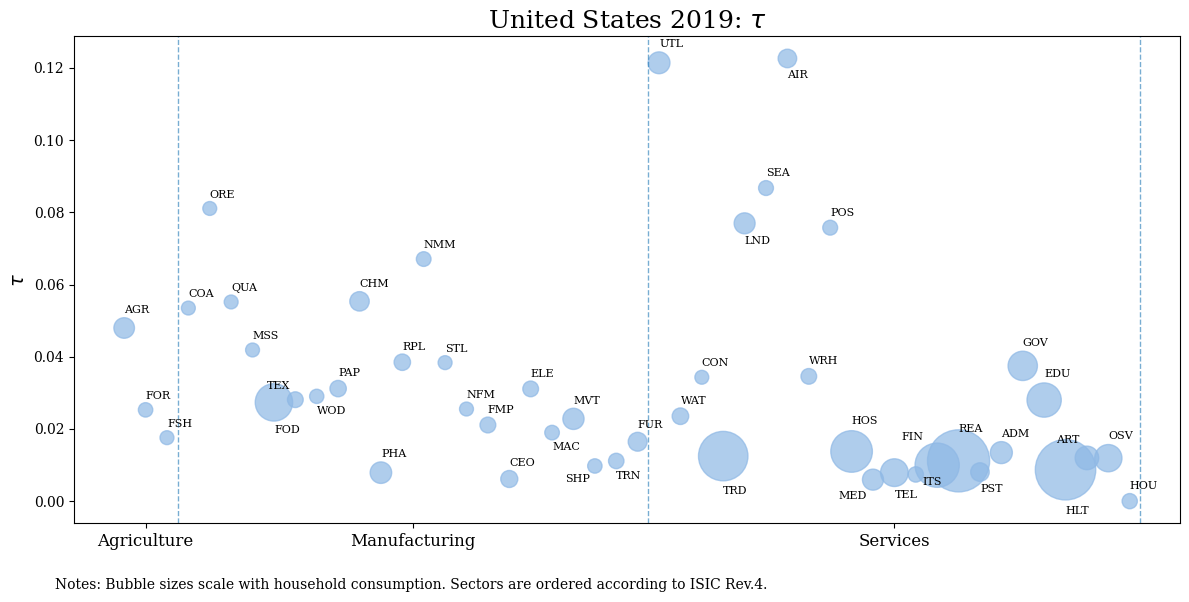

In [18]:
plt.figure(figsize=(13, 5))
metric_labels = {'tau': r'$\tau$', 'tau_dir': r'$\tau_{dir}$', 'tau_amp': r'$\tau_{amp}$', 'tau_amp2': r'$\tau$ with $\tau_{amp}$ tails'}
metric_label = metric_labels.get(metric, metric)
country_name = df['country_name'].dropna().iloc[0] if 'country_name' in df.columns and df['country_name'].notna().any() else country
title = f"{country_name} {year}: {metric_label}"
ax = plot_country_bubble(df, metric=metric, title=title, label_top_n=label_top_n)

plt.figtext(
    0.05, 0.01,
    "Notes: Bubble sizes scale with household consumption. Sectors are ordered according to ISIC Rev.4.",
    ha="left",
    fontsize=10,
    color="black",
    fontfamily="serif",
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('usa_tau_2019.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Try Different Inputs

- Change `country` (e.g., `USA`, `DEU`, `JPN`)
- Change `year` (1995-2022)
- Change `metric` (`tau`, `tau_dir`, `tau_amp`, `tau_amp2`)